<a href="https://colab.research.google.com/github/DiyaGupta512/Cancer-Genomics-and-Drug-Response-Prediction/blob/main/Drug_Response_Prediction_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score,mean_absolute_error
import matplotlib.pyplot as plt
import numpy as np


In [ ]:
df=pd.read_excel("/content/drive/MyDrive/CancerDrugResponse/GDSC1_fitted_dose_response_27Oct23.xlsx")

In [ ]:
df.shape

(333161, 19)

In [ ]:
!pip install ydata-profiling

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 390.9/390.9 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.5/296.5 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 61.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 686.1/686.1 kB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.8/104.8 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 57.6 MB/s eta 0:00:00
  Created wheel for htmlmin: filename=htmlmin-0.1.12-py3-none-any.whl size=27081 sha256=56f2c87e017200aba73922fdecce5bc772d8ea628a761c70e71dbff7528ef979
  Stored in directory: /root/.cache/pip/wheels/dd/91/29/a79cecb328d01739e64017b6fb9a1ab9d8cb1853098ec5966d
Successfully built htmlmin
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.10.0
    Uninstalling matplotlib-3.10.0:
      Successfully uninstalled matplotlib-3.10.0


In [ ]:
from ydata_profiling import ProfileReport
prof = ProfileReport(df)
prof.to_file(output_file='output_drug.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
from google.colab import files
files.download("output_drug.html")

In [ ]:
# Droping constant columns
columns_to_drop = ['DATASET', 'NLME_RESULT_ID', 'WEBRELEASE']
df_cleaned = df.drop(columns=columns_to_drop)

In [ ]:
df_cleaned.columns

Index(['NLME_CURVE_ID', 'COSMIC_ID', 'CELL_LINE_NAME', 'SANGER_MODEL_ID',
       'TCGA_DESC', 'DRUG_ID', 'DRUG_NAME', 'PUTATIVE_TARGET', 'PATHWAY_NAME',
       'COMPANY_ID', 'MIN_CONC', 'MAX_CONC', 'LN_IC50', 'AUC', 'RMSE',
       'Z_SCORE'],
      dtype='object')

In [ ]:
# Check total missing values in each column
missing_per_column = df_cleaned.isnull().sum()
print(missing_per_column[missing_per_column > 0])  # Display columns with missing values

TCGA_DESC           580
PUTATIVE_TARGET    3652
dtype: int64


In [ ]:
# Access the 5th row (index starts at 0)
specific_row = df_cleaned.iloc[1339]
print(specific_row)

NLME_CURVE_ID           15723938
COSMIC_ID                 908441
CELL_LINE_NAME             NCCIT
SANGER_MODEL_ID        SIDM00655
TCGA_DESC                    NaN
DRUG_ID                        6
DRUG_NAME             PHA-665752
PUTATIVE_TARGET              MET
PATHWAY_NAME       RTK signaling
COMPANY_ID                  1045
MIN_CONC                0.007813
MAX_CONC                     2.0
LN_IC50                 2.445839
AUC                     0.981313
RMSE                    0.062283
Z_SCORE                -0.326225
Name: 1339, dtype: object


In [ ]:
# Fill missing values in PUTATIVE_TARGET with its mode (most frequent value)
df_cleaned['PUTATIVE_TARGET'] = df_cleaned['PUTATIVE_TARGET'].fillna(df_cleaned['PUTATIVE_TARGET'].mode()[0])

# Fill missing values in TCGA_DESC with its mode (most frequent value)
df_cleaned['TCGA_DESC'] = df_cleaned['TCGA_DESC'].fillna(df_cleaned['TCGA_DESC'].mode()[0])

In [ ]:
missing_per_column = df_cleaned.isnull().sum()
print(missing_per_column[missing_per_column > 0])  # Display columns with missing values


Series([], dtype: int64)


In [ ]:
# Access the 5th row (index starts at 0)
specific_row = df_cleaned.iloc[1339]
print(specific_row)

NLME_CURVE_ID           15723938
COSMIC_ID                 908441
CELL_LINE_NAME             NCCIT
SANGER_MODEL_ID        SIDM00655
TCGA_DESC           UNCLASSIFIED
DRUG_ID                        6
DRUG_NAME             PHA-665752
PUTATIVE_TARGET              MET
PATHWAY_NAME       RTK signaling
COMPANY_ID                  1045
MIN_CONC                0.007813
MAX_CONC                     2.0
LN_IC50                 2.445839
AUC                     0.981313
RMSE                    0.062283
Z_SCORE                -0.326225
Name: 1339, dtype: object


In [ ]:
df_cleaned.head(2)

,NLME_CURVE_ID,COSMIC_ID,CELL_LINE_NAME,SANGER_MODEL_ID,TCGA_DESC,DRUG_ID,DRUG_NAME,PUTATIVE_TARGET,PATHWAY_NAME,COMPANY_ID,MIN_CONC,MAX_CONC,LN_IC50,AUC,RMSE,Z_SCORE
0,15580432,684057,ES5,SIDM00263,UNCLASSIFIED,1,Erlotinib,EGFR,EGFR signaling,1045,0.007813,2.0,3.966813,0.985678,0.026081,1.299144
1,15580806,684059,ES7,SIDM00269,UNCLASSIFIED,1,Erlotinib,EGFR,EGFR signaling,1045,0.007813,2.0,2.692090,0.972690,0.110059,0.156076


In [ ]:
# Encode categorical variables
label_encoders = {}
categorical_cols = ['CELL_LINE_NAME', 'SANGER_MODEL_ID', 'TCGA_DESC', 'DRUG_NAME', 'PUTATIVE_TARGET', 'PATHWAY_NAME']
for col in categorical_cols:
    label_encoders[col] = LabelEncoder()
    df_cleaned[col] = label_encoders[col].fit_transform(df_cleaned[col])

In [ ]:
df_cleaned.head(5)

,NLME_CURVE_ID,COSMIC_ID,CELL_LINE_NAME,SANGER_MODEL_ID,TCGA_DESC,DRUG_ID,DRUG_NAME,PUTATIVE_TARGET,PATHWAY_NAME,COMPANY_ID,MIN_CONC,MAX_CONC,LN_IC50,AUC,RMSE,Z_SCORE
0,15580432,684057,200,166,30,1,124,73,8,1045,0.007813,2.0,3.966813,0.985678,0.026081,1.299144
1,15580806,684059,202,170,30,1,124,73,8,1045,0.007813,2.0,2.692090,0.972690,0.110059,0.156076
2,15581198,684062,210,116,30,1,124,73,8,1045,0.007813,2.0,2.477990,0.944459,0.087019,-0.035912
3,15581542,684072,809,872,30,1,124,73,8,1045,0.007813,2.0,2.033564,0.950758,0.016290,-0.434437
4,15581930,687448,120,699,26,1,124,73,8,1045,0.007813,2.0,2.966007,0.954778,0.180255,0.401702


In [ ]:
# Select features and target
target = 'LN_IC50'  # Target variable
features = df_cleaned.drop(columns=[target]).columns

In [ ]:
print(features)

Index(['NLME_CURVE_ID', 'COSMIC_ID', 'CELL_LINE_NAME', 'SANGER_MODEL_ID',
       'TCGA_DESC', 'DRUG_ID', 'DRUG_NAME', 'PUTATIVE_TARGET', 'PATHWAY_NAME',
       'COMPANY_ID', 'MIN_CONC', 'MAX_CONC', 'AUC', 'RMSE', 'Z_SCORE'],
      dtype='object')


In [ ]:
df_cleaned.head(5)

,NLME_CURVE_ID,COSMIC_ID,CELL_LINE_NAME,SANGER_MODEL_ID,TCGA_DESC,DRUG_ID,DRUG_NAME,PUTATIVE_TARGET,PATHWAY_NAME,COMPANY_ID,MIN_CONC,MAX_CONC,LN_IC50,AUC,RMSE,Z_SCORE
0,15580432,684057,200,166,30,1,124,73,8,1045,0.007813,2.0,3.966813,0.985678,0.026081,1.299144
1,15580806,684059,202,170,30,1,124,73,8,1045,0.007813,2.0,2.692090,0.972690,0.110059,0.156076
2,15581198,684062,210,116,30,1,124,73,8,1045,0.007813,2.0,2.477990,0.944459,0.087019,-0.035912
3,15581542,684072,809,872,30,1,124,73,8,1045,0.007813,2.0,2.033564,0.950758,0.016290,-0.434437
4,15581930,687448,120,699,26,1,124,73,8,1045,0.007813,2.0,2.966007,0.954778,0.180255,0.401702


In [ ]:
# Scale the quantitative features
scaler = StandardScaler()
df_cleaned[features] = scaler.fit_transform(df_cleaned[features])

In [ ]:
df_cleaned.head(1)

,NLME_CURVE_ID,COSMIC_ID,CELL_LINE_NAME,SANGER_MODEL_ID,TCGA_DESC,DRUG_ID,DRUG_NAME,PUTATIVE_TARGET,PATHWAY_NAME,COMPANY_ID,MIN_CONC,MAX_CONC,LN_IC50,AUC,RMSE,Z_SCORE
0,-1.724997,-1.401247,-1.015847,-1.13005,1.284763,-1.434053,-0.553853,-0.805225,-0.805967,0.630308,-0.114514,-0.115482,3.966813,0.780203,-1.092074,1.299928


In [ ]:
# Define features and target
X = df_cleaned[features]  # Features
y = df_cleaned[target]  # Target

In [ ]:
# Train a temporary Random Forest model to calculate feature importance
rf_temp_model = RandomForestRegressor(n_estimators=30, max_depth=5, random_state=42)
rf_temp_model.fit(X, y)

RandomForestRegressor(max_depth=5, n_estimators=30, random_state=42)

In [ ]:
# Feature importance from Random Forest
feature_importances = pd.DataFrame({
    'Feature': features,
    'Importance': rf_temp_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("Top 10 Important Features:")
print(feature_importances.head(10))

Top 10 Important Features:
            Feature  Importance
12              AUC    0.604662
10         MIN_CONC    0.238255
11         MAX_CONC    0.149916
14          Z_SCORE    0.006680
7   PUTATIVE_TARGET    0.000487
0     NLME_CURVE_ID    0.000000
1         COSMIC_ID    0.000000
2    CELL_LINE_NAME    0.000000
3   SANGER_MODEL_ID    0.000000
4         TCGA_DESC    0.000000


In [ ]:
# Set a threshold for feature importance
importance_threshold = 0.1
selected_features = feature_importances[feature_importances['Importance'] > importance_threshold]['Feature']

In [ ]:
# Update X to only include selected features
X = df_cleaned[selected_features]
print("Selected Features after Filtering:")
print(selected_features)

Selected Features after Filtering:
12         AUC
10    MIN_CONC
11    MAX_CONC
Name: Feature, dtype: object


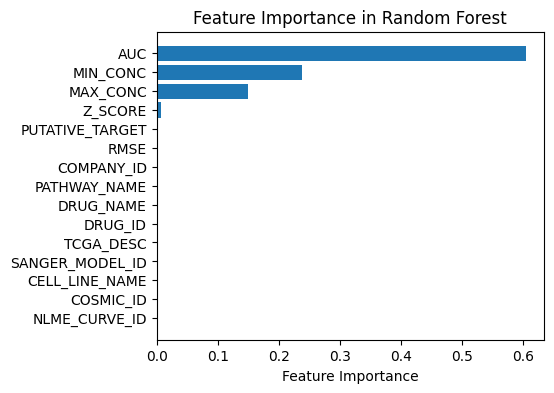

In [ ]:
# Plot feature importances
plt.figure(figsize=(5, 4))
sorted_idx = np.argsort(feature_importances['Importance'])
plt.barh(feature_importances.iloc[sorted_idx]['Feature'], feature_importances.iloc[sorted_idx]['Importance'], align='center')
plt.xlabel('Feature Importance')
plt.title('Feature Importance in Random Forest')
plt.show()

In [ ]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Training the Random Forest model
rf_model = RandomForestRegressor(n_estimators=30, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, n_estimators=30, random_state=42)

In [ ]:
y_pred_rf = rf_model.predict(X_test)

In [ ]:
# Evaluating Random Forest
rf_mse = mean_squared_error(y_test, y_pred_rf) # mean squared error
rf_r2 = r2_score(y_test, y_pred_rf) # cofficient of variance
rf_mae = mean_absolute_error(y_test, y_pred_rf) # mean absolute error
print("\nRandom Forest Results:")
print(f"MSE: {rf_mse}")
print(f"R2 Score: {rf_r2}")
print(f"MAE: {rf_mae}")



Random Forest Results:
MSE: 0.1625796135578997
R2 Score: 0.9757732610492212
MAE: 0.2802481854898151


In [ ]:
#comparison
comparison_df = pd.DataFrame({
    'Actual': y_test[:10],
    'Predicted': y_pred_rf[:10],
    'Difference': y_test[:10] - y_pred_rf[:10]
})

print(comparison_df)

          Actual  Predicted  Difference
34043   1.476003   1.760528   -0.284525
271097  4.114941   4.124271   -0.009330
74490   3.556466   3.392487    0.163979
293166  3.111808   3.219222   -0.107414
332114  4.932949   4.515267    0.417682
99172   3.590363   3.289735    0.300628
274527  2.743642   2.617824    0.125818
247239  3.231801   3.043858    0.187943
98201   4.366367   4.141663    0.224704
128975  0.828223   0.735403    0.092820
